In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import joblib
from tqdm import tqdm
from pathlib import Path
import networkx as nx
from scipy.spatial.distance import pdist, squareform

from ou_model import forward, backward, score, classify, theoretical_ts
from plotting import plot_speciation_3d, plot_sagd_heatmap_row
from SASNE import SASNE
from RRP import RRP

from SASNE import AdaptiveKNNGraph
from plotting import plot_sagd_heatmap_row
from animations import create_ctd_synchronized_animation

### Toy example - small d and n

In [2]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star, std = torch.tensor([4.0, 4.0]), 1.0

In [3]:
small_n_path_history = []
# Start with pure random noise at t=T 
small_n_x_current = torch.randn(d, nsamples_small_n) 

for t in tqdm(times):
    small_n_path_history.append(small_n_x_current.T.clone().numpy()) 
    small_n_x_current, _ = backward(small_n_x_current, t, dt, mu_star, std)
    
small_n_path_history = np.array(small_n_path_history)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 21526.03it/s]


Since we can solve the score function analytically, we just need to sample using he backward process
The particles' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class. Since we know the exact form of the score function there is not a collapse time.

In [4]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482537641375833


#### Visualize trajectories

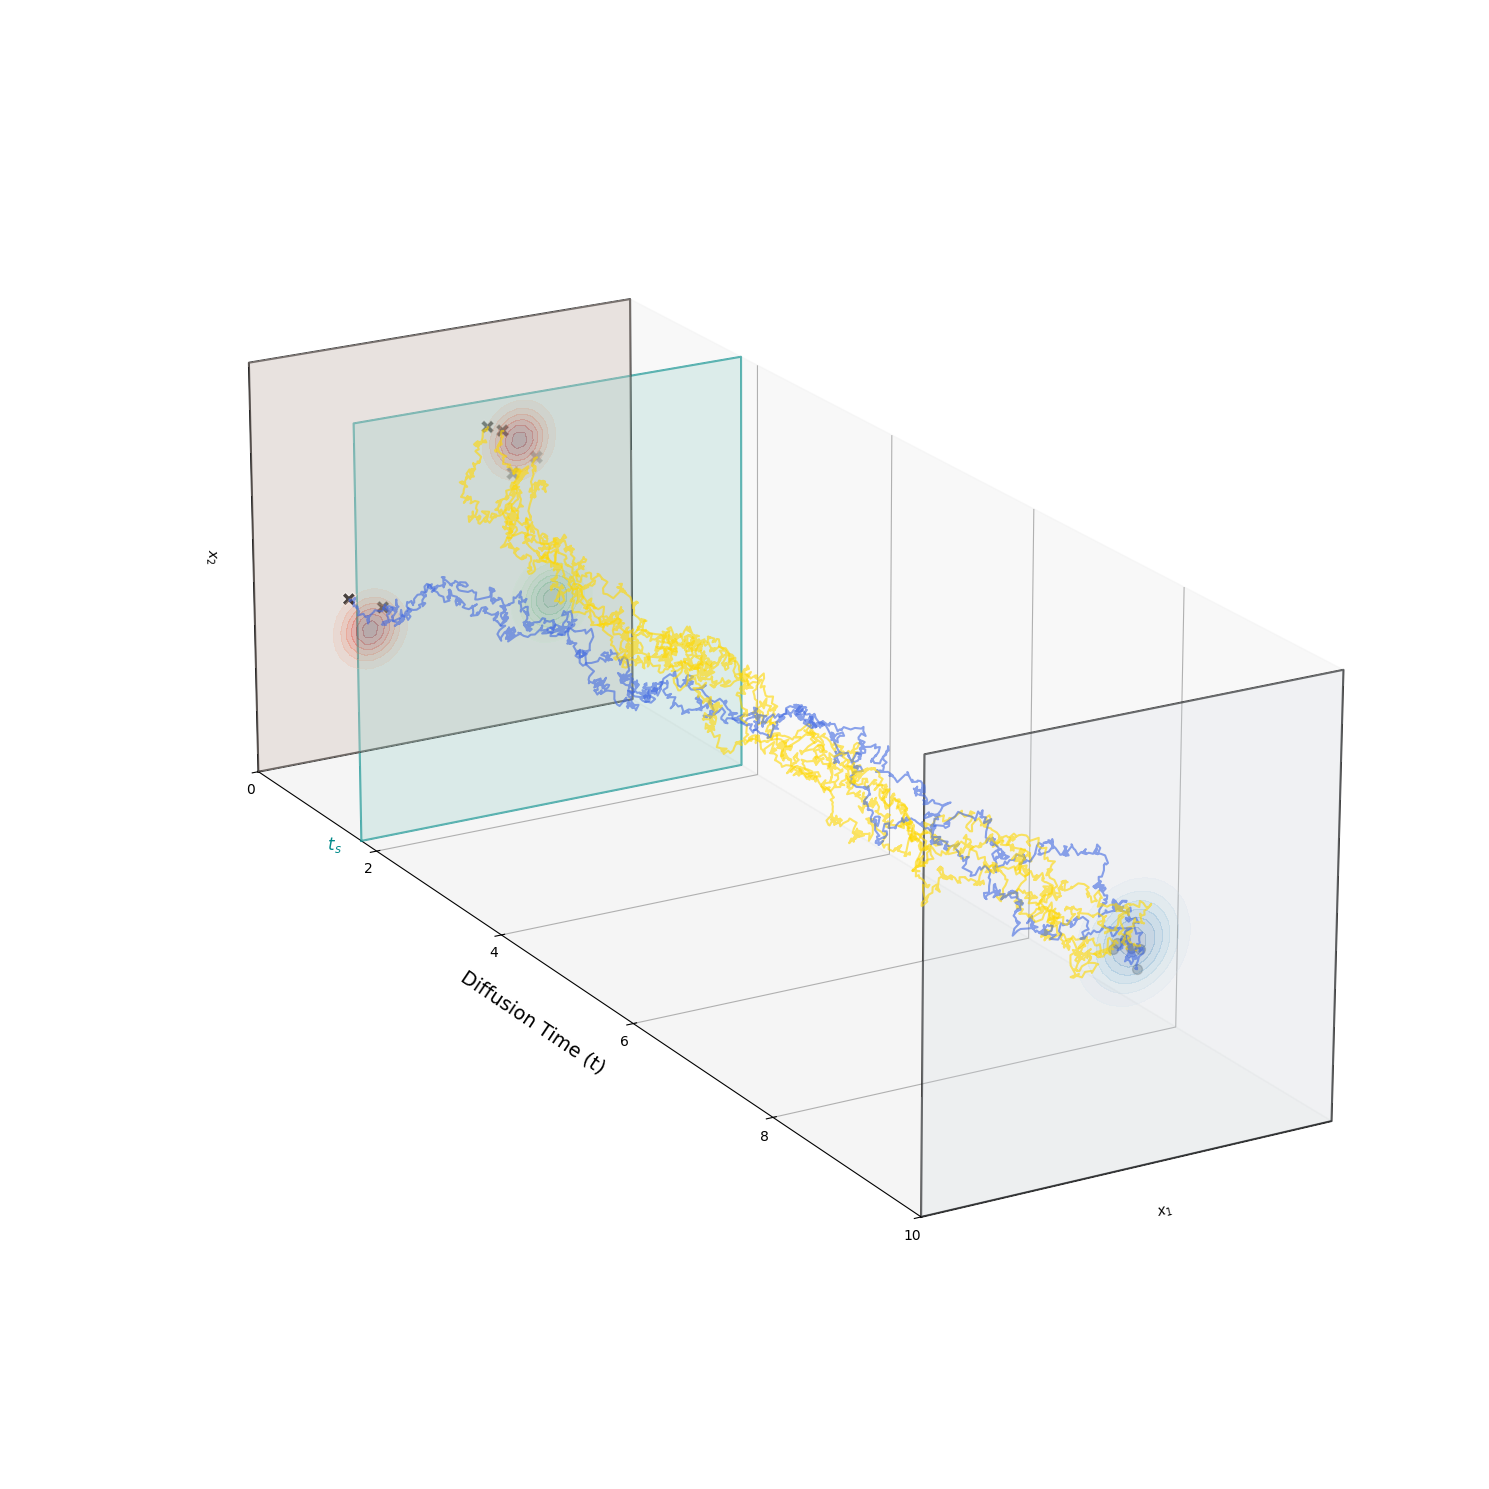

In [5]:
plot_speciation_3d(
    path_history=small_n_path_history,
    times=times,
    mu_star=mu_star,
    std=std,
    nsamples=nsamples_small_n,
    t_s=t_s,
    save_fig_path='../figures/diffusion_trajectories.png',
    t_c=None
)

### Knn graph from data at different time steps

In [5]:
d=2
path = Path('../data/exp_01')
loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
large_n_path_history = loaded_data["history"]
time_snaps = list(large_n_path_history.keys())
tsm, ts_idx = theoretical_ts(mu_star, std, times)
ts_idx = np.argmin(np.abs(time_snaps - t_s))
X_T = torch.as_tensor(large_n_path_history[0], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
knn_objs = []

for idx in [0, ts_idx, -1]:
    knn_obj = AdaptiveKNNGraph(large_n_path_history[time_snaps[idx]], inject_edges=True, kernel='gaussian')
    W = knn_obj.compute_W()
    k = knn_obj.k
    knn_objs.append((W, k))

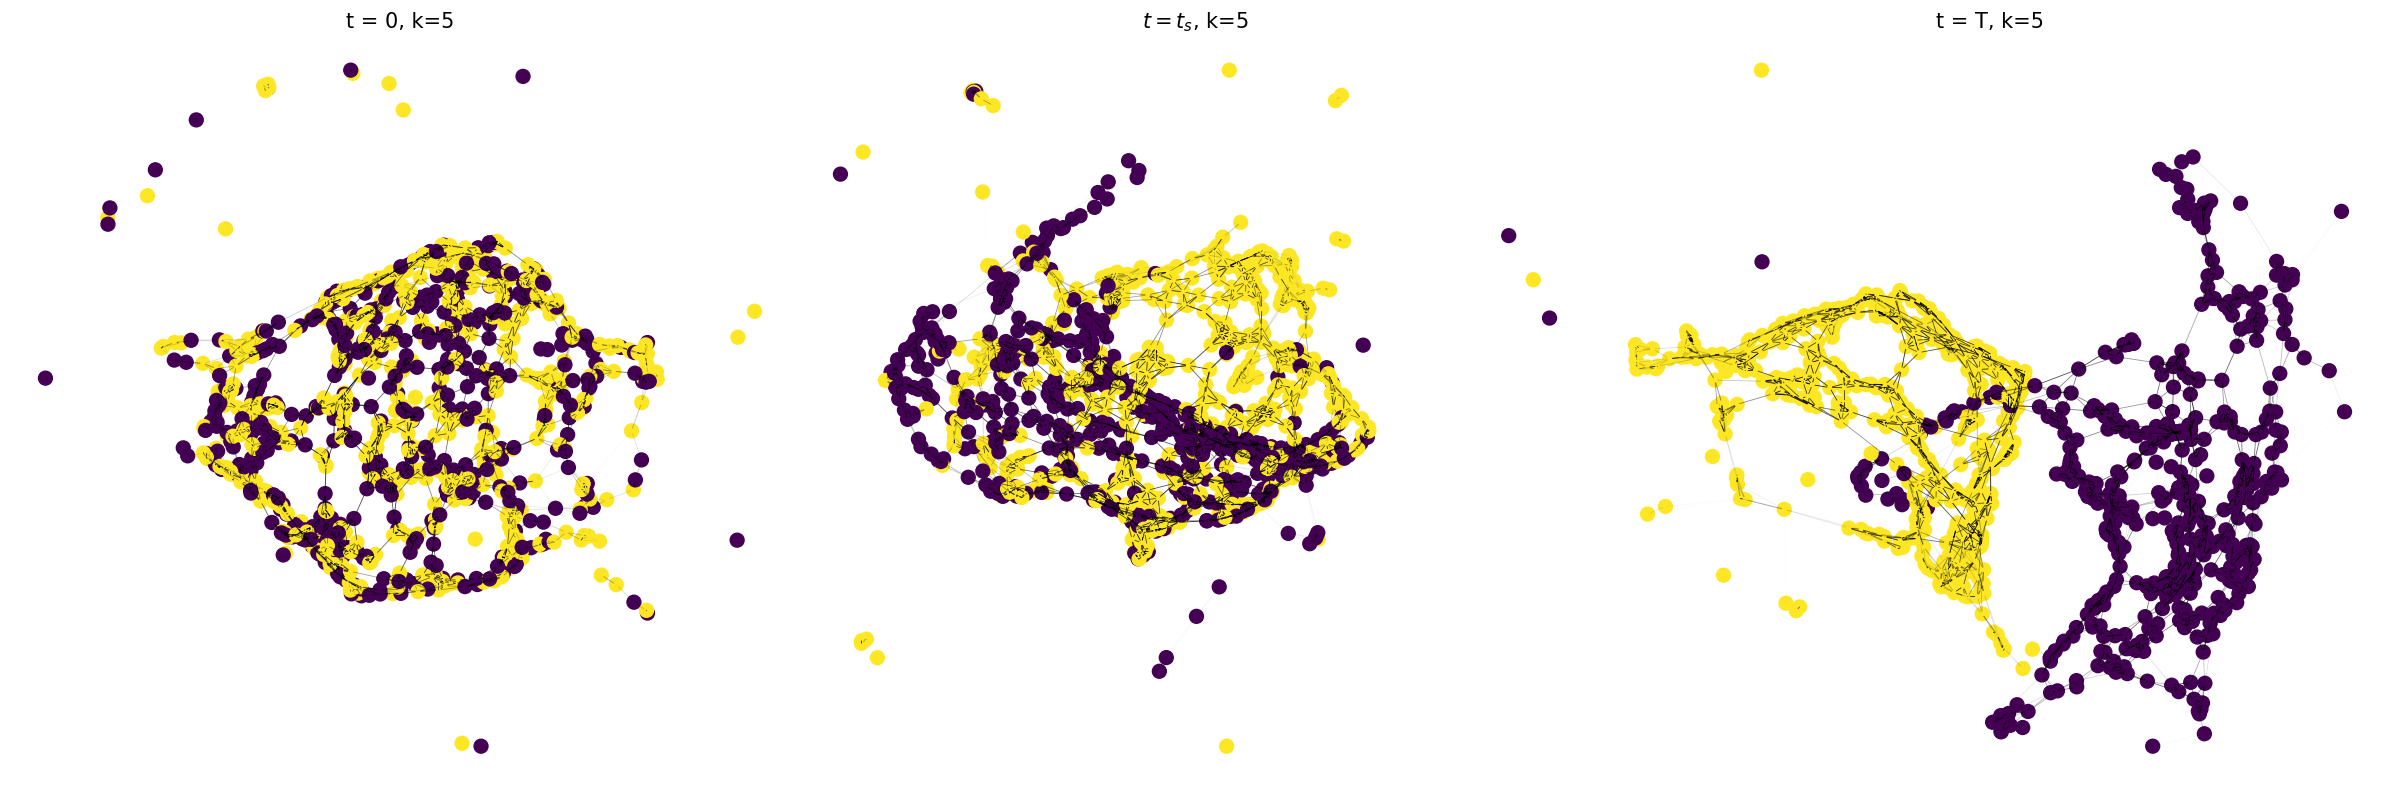

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$", "t = T"]
for i, obj in enumerate(knn_objs):
    W, k = obj
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i] + f", k={k}", fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()

### SASNE projection of the SAGS distance matrix for higher dimensions

In [7]:
ds = sorted([int(i.name.rsplit('_')[0].rsplit('D')[1]) for i in path.iterdir() if 'D' in i.name ])

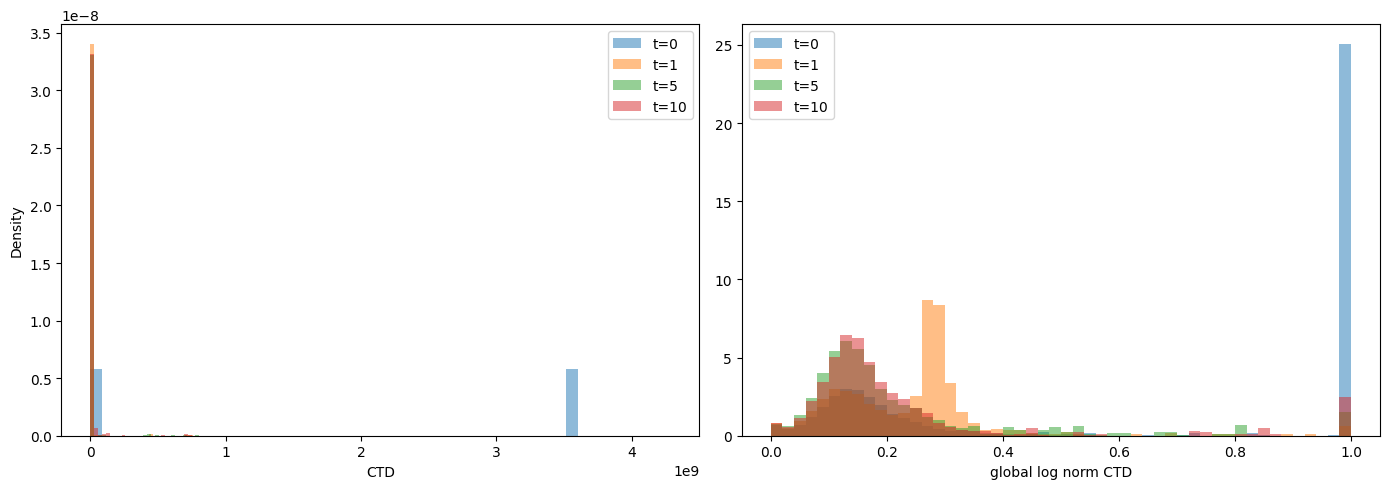

In [8]:
d=2
CTDs= joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
t_values = [0, 1, 5, 10]
temp = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ctds_dict = CTDs['CTDs']
for t in t_values:
    ctds = ctds_dict[t]['ctds']
    axes[0].hist(ctds, bins=50, alpha=0.5, label=f't={t}', density=True)
    # Global Log scale
    norm_ctds = ctds_dict[t]['norm_ctds']
    axes[1].hist(norm_ctds, bins=50, alpha=0.5, label=f't={t}', density=True)
axes[0].set_xlabel('CTD')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[1].set_xlabel('global log norm CTD')
axes[1].legend()
plt.savefig('norm.png')
plt.tight_layout()
plt.show()

In [ ]:
SAGD_dist_matrix_list = []
for d in ds:
    loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
    CTDs= joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
    T = loaded_data['params']['T']
    n_steps = loaded_data['params']['n_steps']
    dt = T / n_steps
    time_snaps = loaded_data['params']['times_snapshots']
    t_s = loaded_data['params']["ts_theoretical"]
    ts_idx = np.argmin(np.abs(time_snaps - t_s))
    SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")
    SAGD_dist_matrix_list.append((SAGD_dist_matrix, time_snaps,  t_s, ts_idx))

In [ ]:
plot_sagd_heatmap_row(
        W_list=[matrix for matrix, *_ in SAGD_dist_matrix_list],
        d_list=ds,
        time_snaps_vector_list=[time_snaps for _, time_snaps, *_ in SAGD_dist_matrix_list],
        ts_tuple_list=[(t_s, ts_idx) for *_, t_s, ts_idx in SAGD_dist_matrix_list],
        save_fig_path='sagd_dm.png'
)

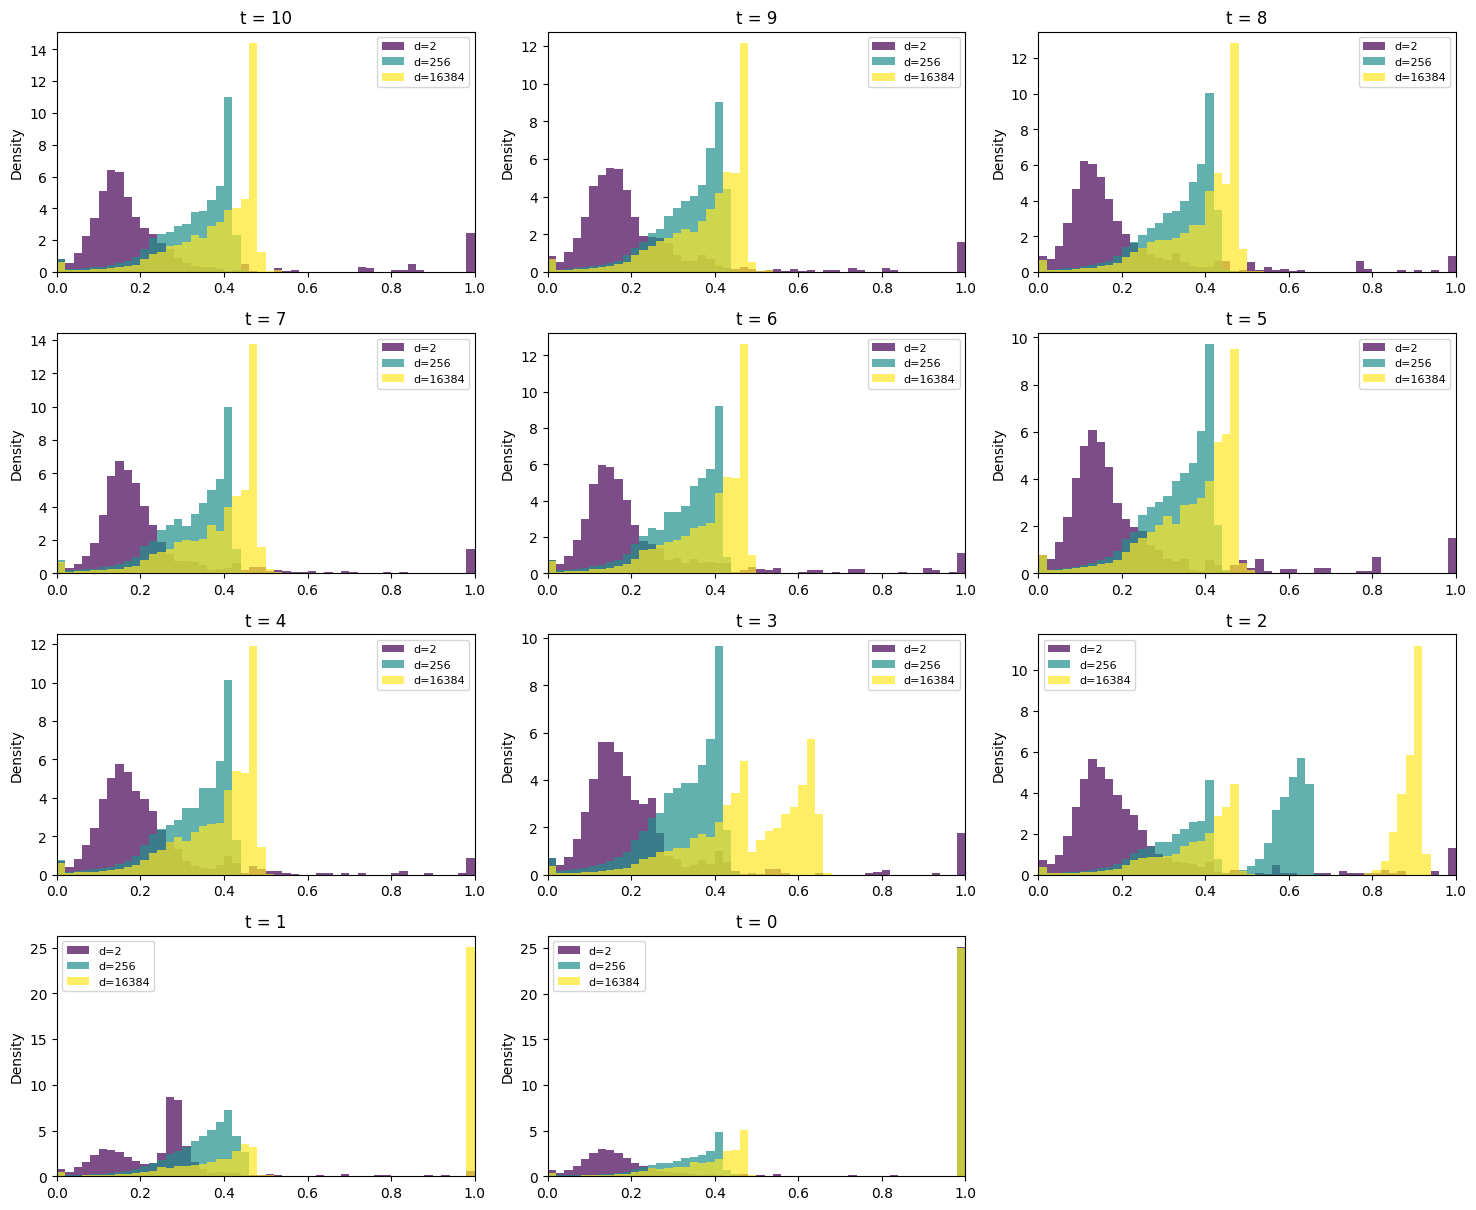

In [11]:
ds = [2, 256, 16384] 
colors = plt.cm.viridis(np.linspace(0, 1, len(ds)))

data = {}
for d in ds:
    data[d] = joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
    
shared_bins = np.linspace(0, 1, 51)
t_subset = sorted([t for t in CTDs['CTDs'].keys() if 0.5 <= t <= 2.0])
n = len(t_subset)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()
for i, t in enumerate(range(0, 11, 1)[::-1]):
    for idx, d in enumerate(ds):
        axes[i].hist(data[d]['CTDs'][t]['norm_ctds'], bins=shared_bins, alpha=0.7, density=True, 
                    color=colors[idx], label=f'd={d}')
        
        axes[i].set_title(f't = {round(t, 3)}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlim(0, 1)
        axes[i].legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
save_path = 'exmp.png'
if save_path:
    plt.savefig(save_path)
plt.show()

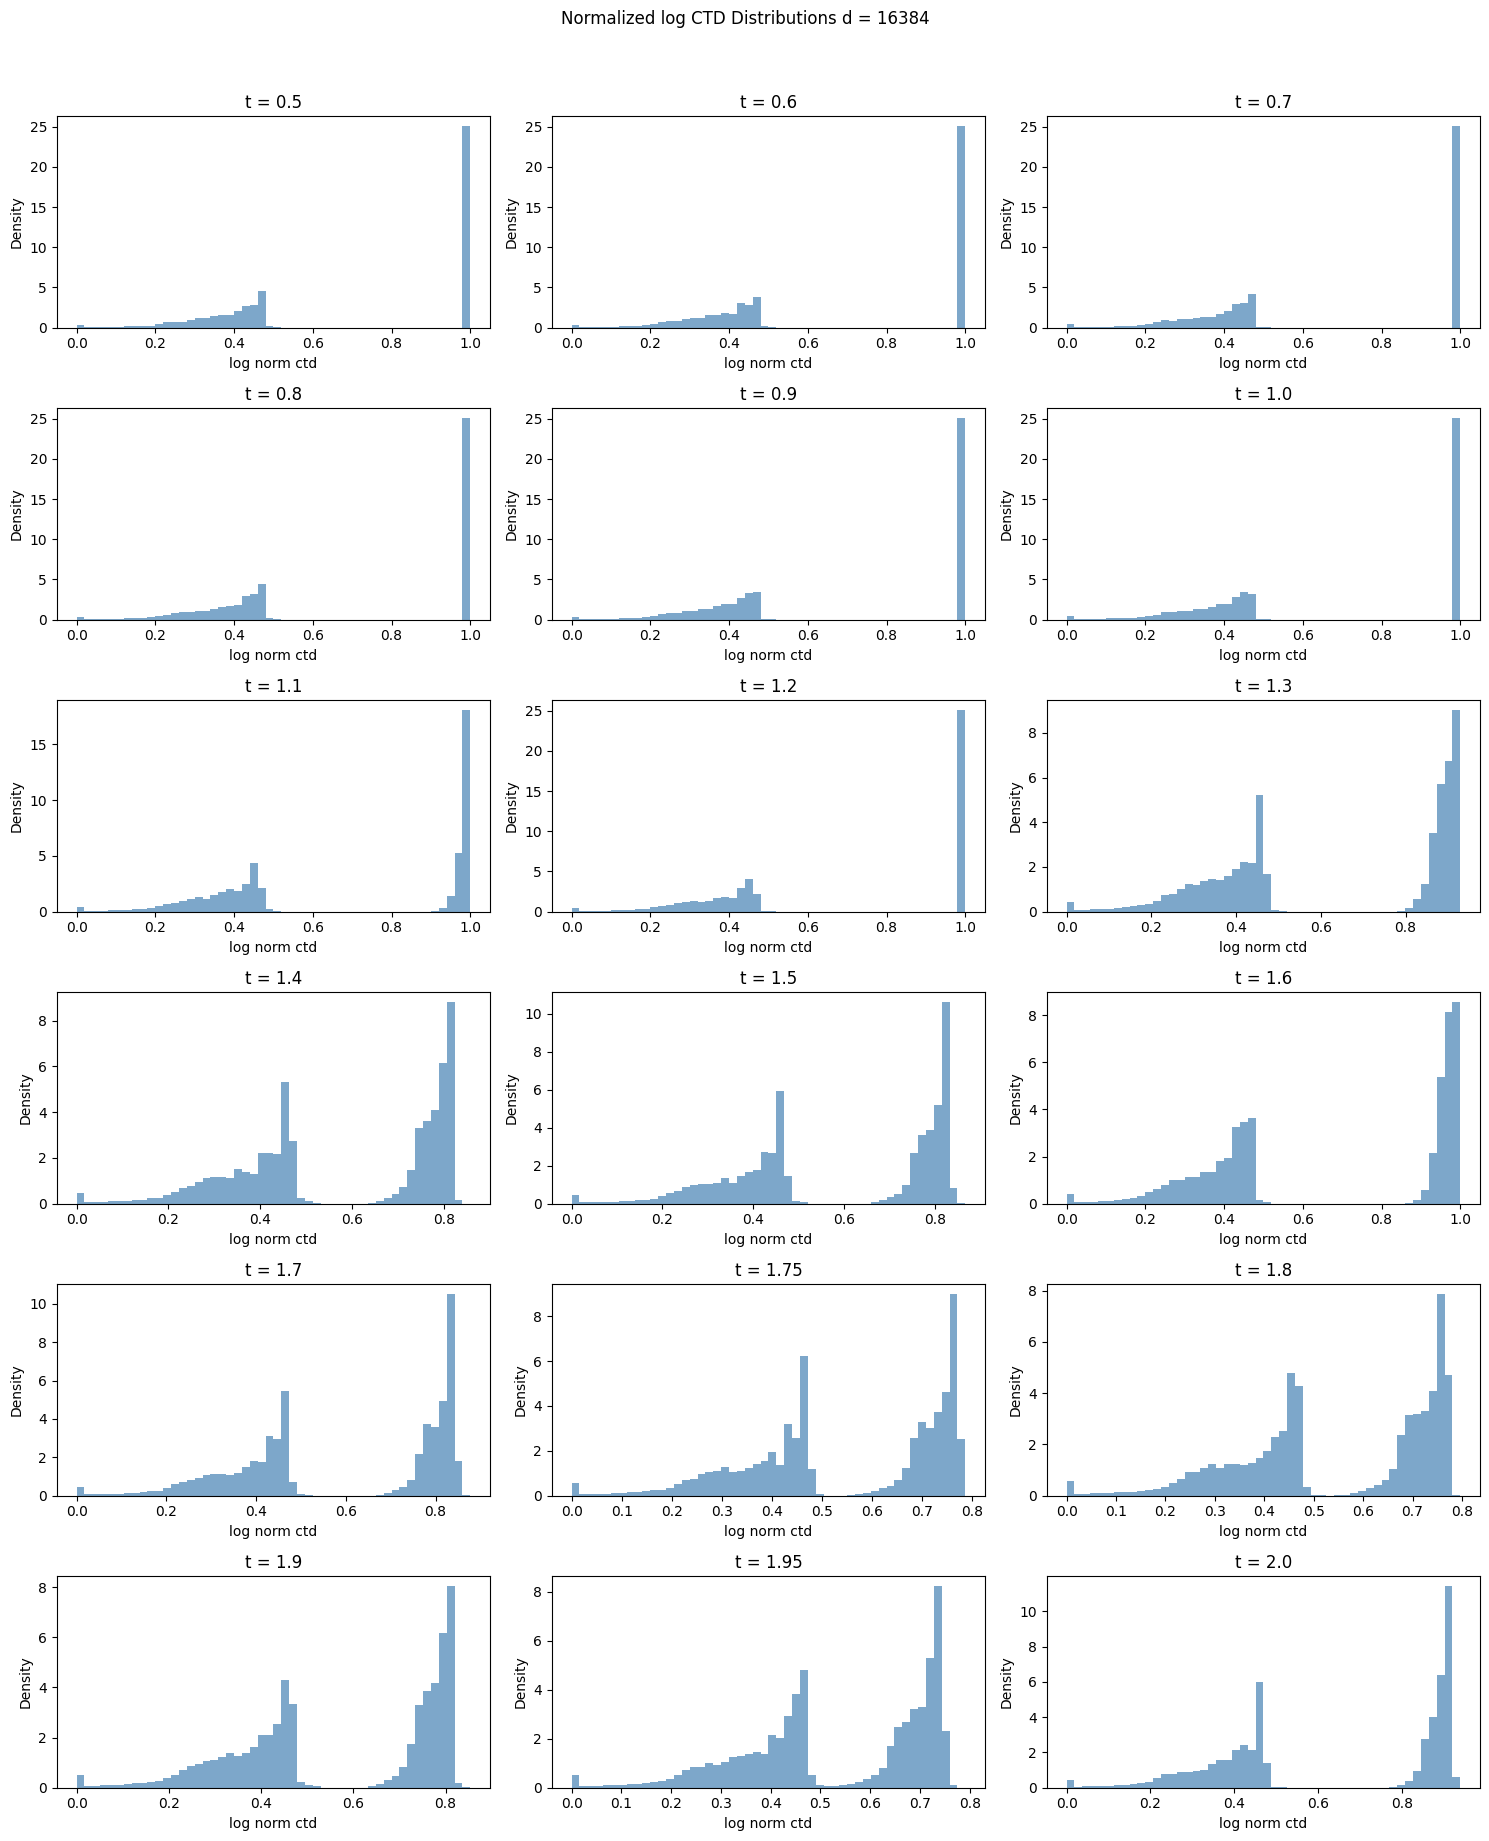

In [12]:
d = 16384
CTDs = data[d]
t_values = [t for t in CTDs['CTDs'].keys() if 0.5 <= t <= 2.0]
t_values = sorted(t_values)

n = len(t_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, t in enumerate(t_values):
    log_ctds = np.array(CTDs['CTDs'][t]['norm_ctds'])
    axes[i].hist(log_ctds, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[i].set_title(f't = {round(t, 3)}')
    axes[i].set_xlabel('log norm ctd')
    axes[i].set_ylabel('Density')

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Normalized log CTD Distributions d = {d}', y=1.02)
plt.savefig('norm_ctds.png')
plt.tight_layout()
plt.show()

In [16]:
d = 16384
CTDs = joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")
time_snaps = loaded_data['params']['times_snapshots']
t_s = loaded_data['params']["ts_theoretical"]
ts_idx = np.argmin(np.abs(time_snaps - t_s))
ctds = [CTDs['CTDs'][t]['norm_ctds'] for t in time_snaps]

create_ctd_synchronized_animation(
    d=16384,
    ctds_list=ctds,
    time_snaps=time_snaps,    
    ts=t_s,                  
    ts_idx=ts_idx,           
    SAGD_dist_matrix=SAGD_dist_matrix, 
    save_path='D16384_ctds_progression.gif'
)